# NACA 4412 (Dataset) vs NACA 2412 (Analytical)  
**Objective:** Load and clean the provided NACA 4412 dataset, perform thorough EDA, extract a clean airfoil profile, generate a reference NACA 2412 airfoil by formula, compare both profiles in 2D and 3D and export cleaned 2D/3D geometry files suitable for portfolio inclusion and downstream use.


## Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mpl_toolkits.mplot3d import Axes3D

plt.rcParams.update({'figure.dpi':120})
sns.set_style("whitegrid")
os.makedirs('data', exist_ok=True)


## Load dataset

In [4]:
file_path = r"C:\Users\works\Desktop\4412.csv"
df = pd.read_csv(file_path)
df.head(8)


,p,U:0,U:1,U:2,Points:0,Points:1,Points:2
0,-1117.6,-9.8344,55.078,5.349000e-19,-0.000020,0.000103,0
1,-1120.1,-9.8722,55.115,-5.775900e-20,-0.000008,0.000105,0
2,-1115.1,-9.7955,55.039,-8.066400e-20,-0.000033,0.000100,0
3,-1122.5,-9.9089,55.152,3.169500e-19,0.000004,0.000107,0
4,-1112.5,-9.7556,54.999,-4.608500e-19,-0.000046,0.000098,0
5,-1124.8,-9.9446,55.187,-6.601000e-21,0.000016,0.000110,0
6,-1109.9,-9.7144,54.957,-5.032300e-19,-0.000060,0.000095,0
7,-1127.1,-9.9790,55.220,-8.752600e-19,0.000027,0.000112,0


In [5]:
print("Shape:", df.shape)
display(df.dtypes)
display(df.isnull().sum())
display(df.duplicated().sum())
display(df.describe(include='all').T)


Shape: (999000, 7)


p           float64
U:0         float64
U:1         float64
U:2         float64
Points:0    float64
Points:1    float64
Points:2      int64
dtype: object

p           0
U:0         0
U:1         0
U:2         0
Points:0    0
Points:1    0
Points:2    0
dtype: int64

np.int64(0)

,count,mean,std,min,25%,50%,75%,max
p,999000.0,-6.109580e+01,3.055848e+02,-1.998400e+03,-2.371050e+01,0.668790,6.201000e+01,4.499600e+02
U:0,999000.0,2.535199e+01,1.039414e+01,-2.067300e+01,2.210600e+01,29.277000,2.962200e+01,5.166300e+01
U:1,999000.0,4.296285e+00,7.699095e+00,-5.125500e+00,4.084175e-01,4.456750,5.217700e+00,6.581400e+01
U:2,999000.0,1.026770e-22,2.887145e-19,-9.227000e-18,-3.619575e-20,0.000000,3.629200e-20,8.966300e-18
Points:0,999000.0,7.892847e-01,7.090253e+01,-5.450300e+02,2.084850e-02,0.678670,1.002125e+00,5.490200e+02
Points:1,999000.0,-4.948998e-02,7.110655e+01,-5.489400e+02,-2.241200e-01,0.000159,2.360000e-01,5.480000e+02
Points:2,999000.0,5.000000e-01,5.000003e-01,0.000000e+00,0.000000e+00,0.500000,1.000000e+00,1.000000e+00


## Column normalization and numeric coercion
Standardize column names and coerce all columns to numeric where possible.


In [6]:
orig_cols = df.columns.tolist()
cols_map = {}
for c in orig_cols:
    c2 = c.strip()
    c2 = c2.replace(':','_').replace(' ','_')
    cols_map[c] = c2
df = df.rename(columns=cols_map)
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df = df.reset_index(drop=True)
df.head(6)


,p,U_0,U_1,U_2,Points_0,Points_1,Points_2
0,-1117.6,-9.8344,55.078,5.349000e-19,-0.000020,0.000103,0
1,-1120.1,-9.8722,55.115,-5.775900e-20,-0.000008,0.000105,0
2,-1115.1,-9.7955,55.039,-8.066400e-20,-0.000033,0.000100,0
3,-1122.5,-9.9089,55.152,3.169500e-19,0.000004,0.000107,0
4,-1112.5,-9.7556,54.999,-4.608500e-19,-0.000046,0.000098,0
5,-1124.8,-9.9446,55.187,-6.601000e-21,0.000016,0.000110,0


##  Remove constant or near-constant columns
Drop columns with virtually no variance to reduce noise.


In [7]:
var_series = df.var(numeric_only=True)
low_var_cols = var_series[var_series <= 1e-12].index.tolist()
if low_var_cols:
    df = df.drop(columns=low_var_cols)
df.shape, low_var_cols


((999000, 6), ['U_2'])

##  Univariate exploration
Plot histograms and boxplots for numeric features to inspect distributions and outliers.


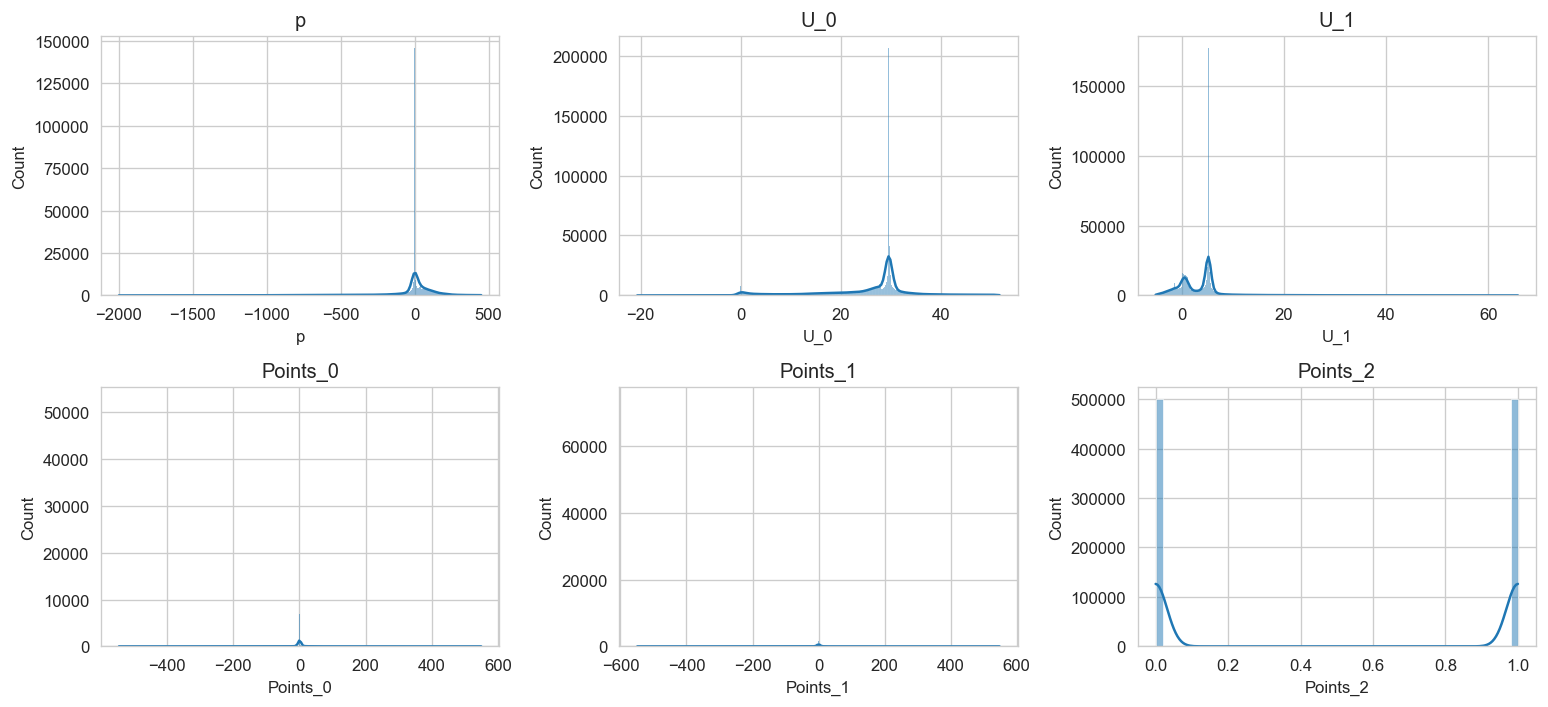

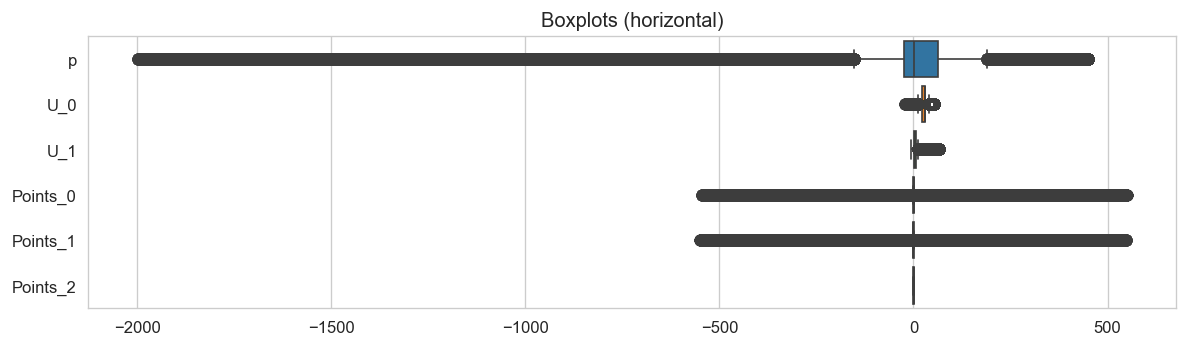

In [8]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
n = len(num_cols)
cols = 3
rows = int(np.ceil(n/cols))
fig, axes = plt.subplots(rows, cols, figsize=(13, 3*rows))
axes = axes.flatten()
for i, c in enumerate(num_cols):
    sns.histplot(df[c].dropna(), ax=axes[i], kde=True)
    axes[i].set_title(c)
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10,3))
sns.boxplot(data=df[num_cols], orient='h', ax=ax)
plt.title('Boxplots (horizontal)')
plt.tight_layout()
plt.show()


##  Correlation and pairwise relationships
Compute correlation matrix and show pairwise scatter sample.


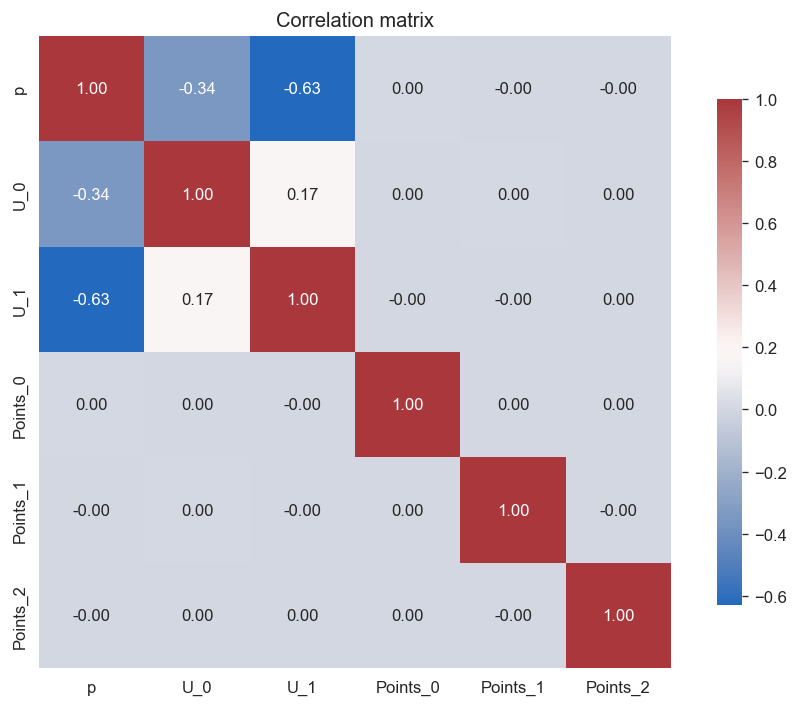

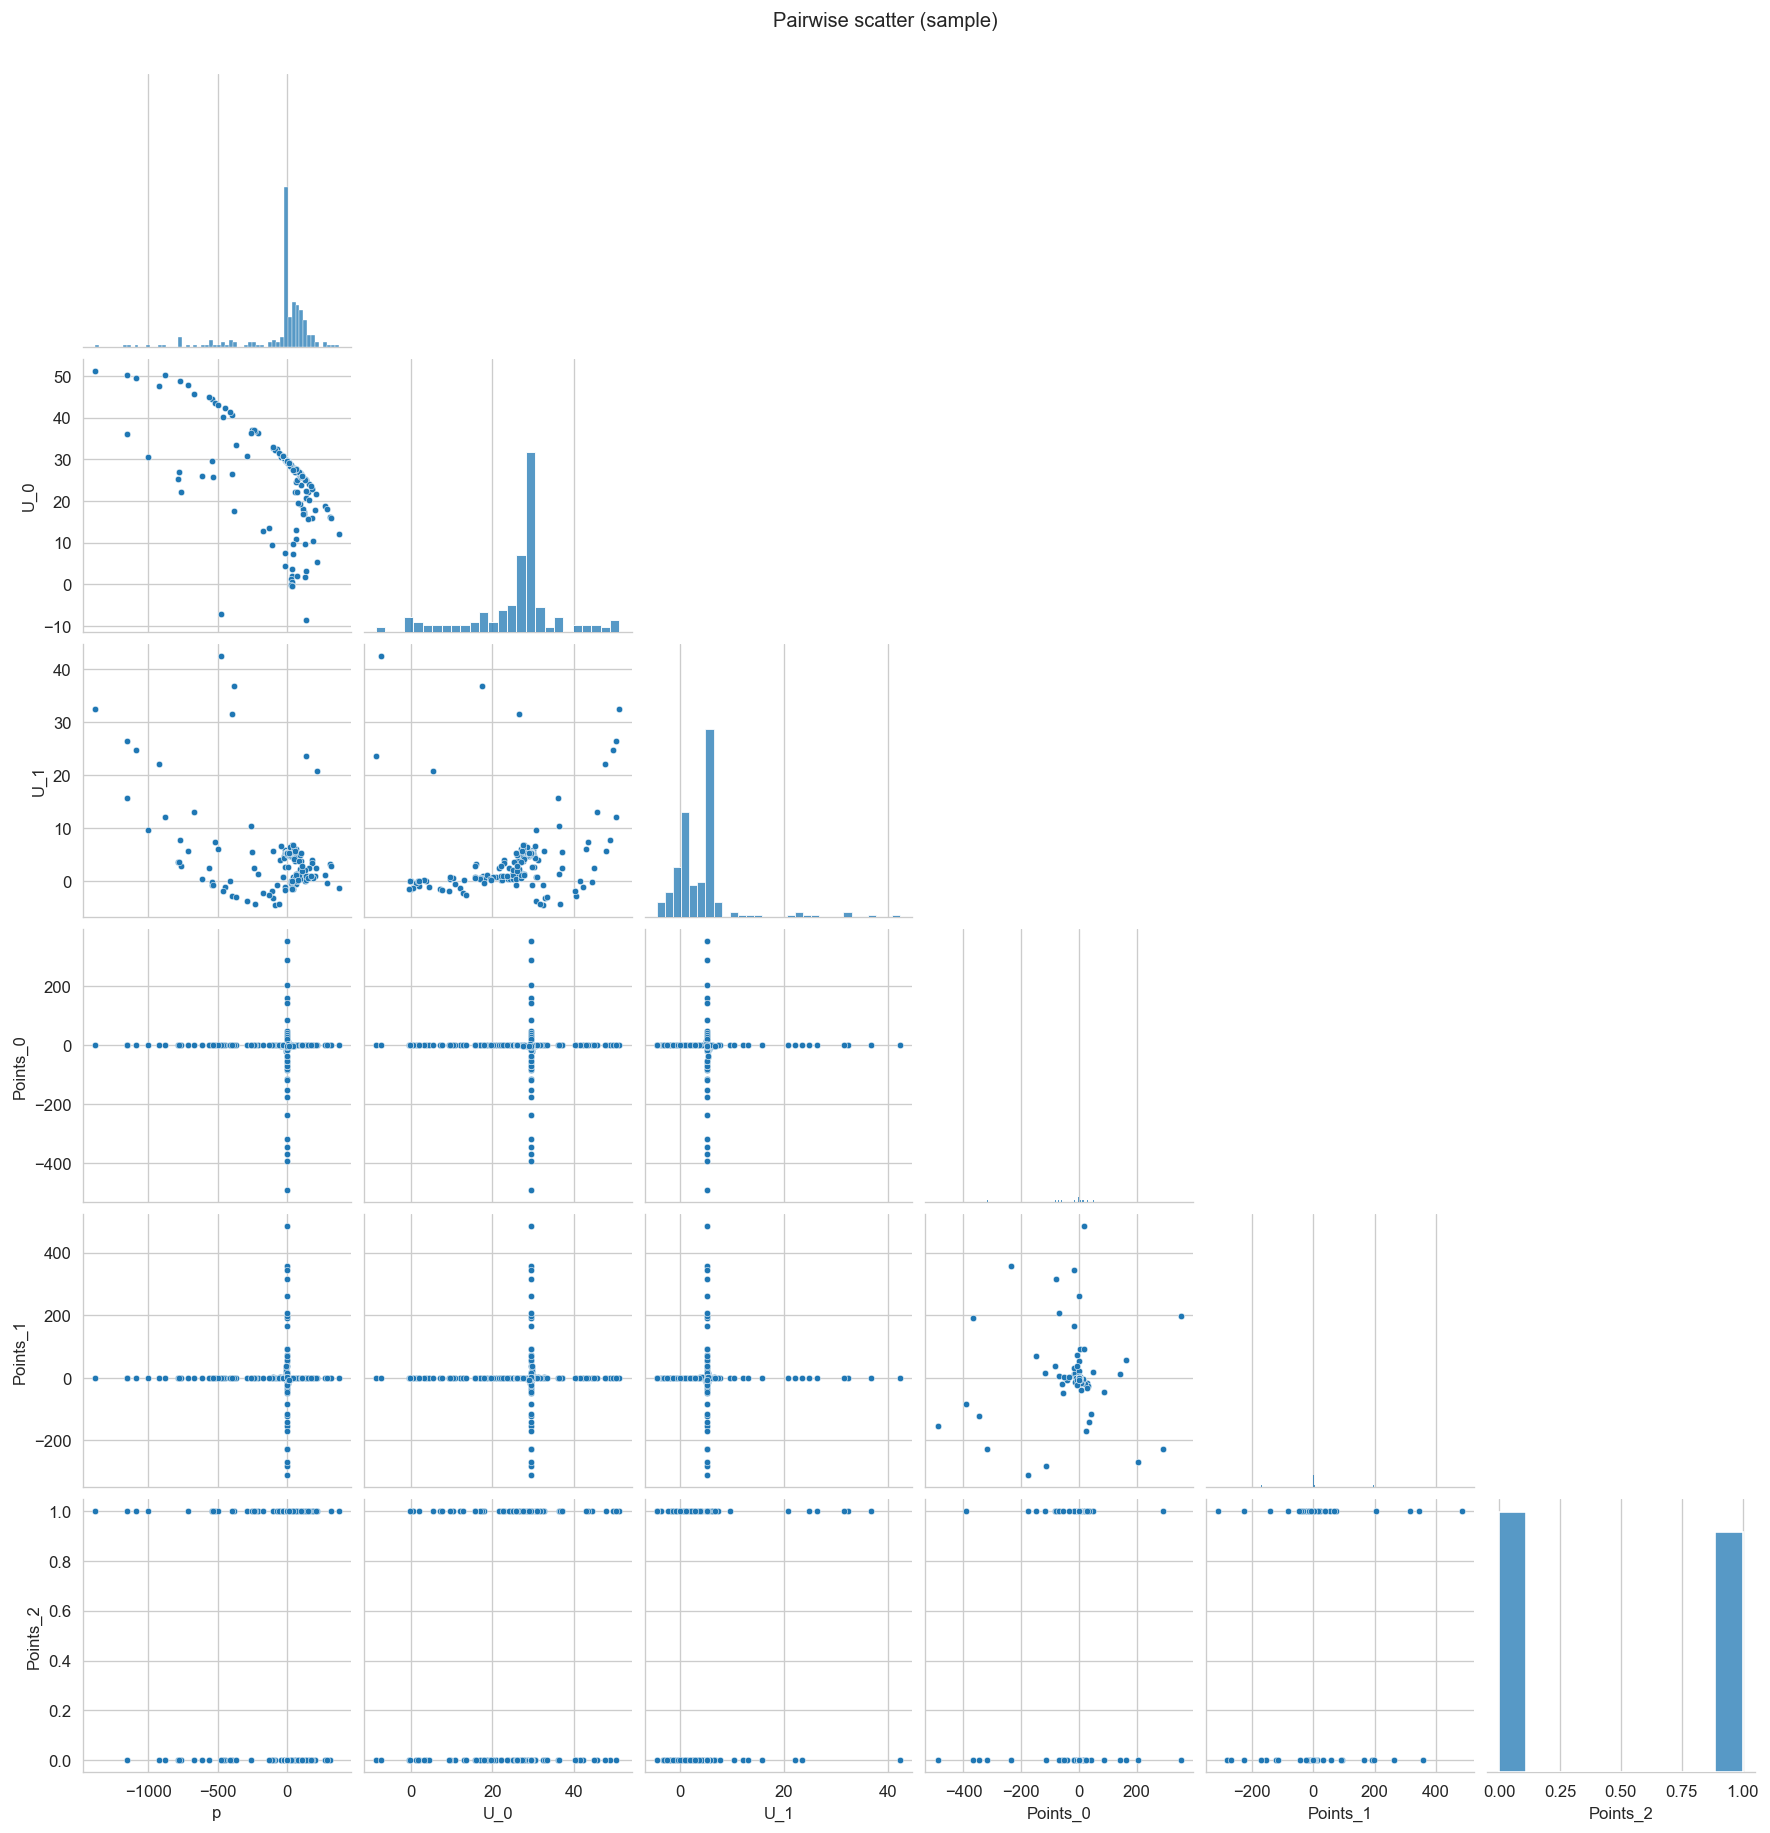

In [9]:
corr = df[num_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', square=True, cbar_kws={'shrink':0.8})
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

sample = df[num_cols].sample(n=min(200, len(df)), random_state=42)
sns.pairplot(sample, corner=True, plot_kws={'s':15})
plt.suptitle('Pairwise scatter (sample)', y=1.02)
plt.show()


##  Coordinate selection strategy
Prefer columns named like `Points_*` for geometry. If unavailable, use a smoothness heuristic across numeric column pairs to pick the most likely (x,y) pair representing an airfoil profile.


In [10]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

candidate_x = None
candidate_y = None
points_cols = [c for c in numeric_cols if c.lower().startswith('points') or 'point' in c.lower()]
if len(points_cols) >= 2:
    candidate_x, candidate_y = points_cols[0], points_cols[1]
else:
    def smoothness_metric(x, y):
        mask = (~np.isnan(x)) & (~np.isnan(y))
        if mask.sum() < 10:
            return np.inf
        xs = np.array(x[mask])
        ys = np.array(y[mask])
        idx = np.argsort(xs)
        xs_s = xs[idx]
        ys_s = ys[idx]
        tv = np.sum(np.abs(np.diff(ys_s)))
        rng = np.ptp(xs_s) if np.ptp(xs_s) != 0 else 1.0
        return tv / rng
    pairs = []
    for xi in numeric_cols:
        for yi in numeric_cols:
            if xi == yi:
                continue
            metric = smoothness_metric(df[xi].values, df[yi].values)
            pairs.append((xi, yi, metric))
    pairs_sorted = sorted(pairs, key=lambda x: x[2])
    candidate_x, candidate_y = pairs_sorted[0][0], pairs_sorted[0][1]

candidate_x, candidate_y


('Points_0', 'Points_1')

##  Chosen columns for geometry
The notebook selected the following columns as x and y. Inspect the scatter to confirm the profile resembles an airfoil curve.


Chosen x: Points_0 Chosen y: Points_1


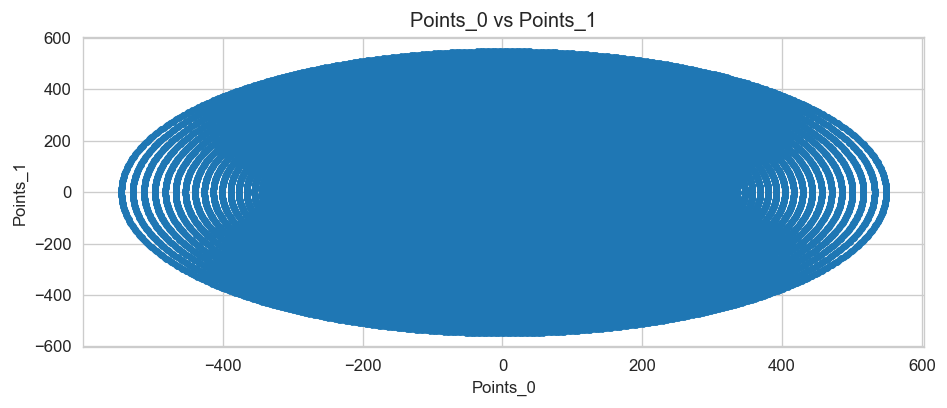

In [11]:
print("Chosen x:", candidate_x, "Chosen y:", candidate_y)
plt.figure(figsize=(8,3.5))
plt.scatter(df[candidate_x], df[candidate_y], s=8)
plt.title(f'{candidate_x} vs {candidate_y}')
plt.xlabel(candidate_x)
plt.ylabel(candidate_y)
plt.tight_layout()
plt.show()


## Clean, normalize, and orient coordinates
Remove NaNs/duplicates, sort by x, normalize x to [0,1], center y, smooth minor noise, and export cleaned 2D coordinates.


In [12]:
coords = df[[candidate_x, candidate_y]].rename(columns={candidate_x:'x_raw', candidate_y:'y_raw'}).dropna().copy()
coords = coords.drop_duplicates().reset_index(drop=True)
coords = coords.sort_values('x_raw').reset_index(drop=True)
x_min, x_max = coords['x_raw'].min(), coords['x_raw'].max()
if x_max > x_min:
    coords['x'] = (coords['x_raw'] - x_min) / (x_max - x_min)
else:
    coords['x'] = coords['x_raw']
coords['y'] = coords['y_raw'] - coords['y_raw'].median()

coords['y_smooth'] = coords['y'].rolling(window=5, center=True, min_periods=1).median()
coords_clean = coords[['x','y_smooth']].rename(columns={'y_smooth':'y'}).reset_index(drop=True)
coords_clean.to_csv('data/naca4412_cleaned_coordinates.csv', index=False)
coords_clean.head(8)


,x,y
0,0.000000,0.475171
1,0.000009,-1.252744
2,0.000018,0.475171
3,0.000037,-2.980659
4,0.000055,3.931041
5,0.000082,-6.436459
6,0.000110,7.386641
7,0.000146,-9.891959


##  2D Airfoil Profile — NACA 4412 (cleaned from dataset)


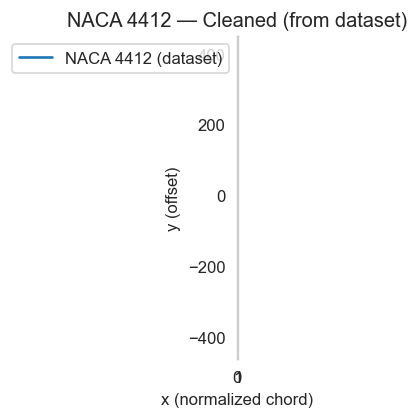

In [13]:
plt.figure(figsize=(9,3.6))
plt.plot(coords_clean['x'], coords_clean['y'], linewidth=1.6, label='NACA 4412 (dataset)')
plt.gca().set_aspect('equal', adjustable='box')
plt.title('NACA 4412 — Cleaned (from dataset)')
plt.xlabel('x (normalized chord)')
plt.ylabel('y (offset)')
plt.grid(linestyle='--', linewidth=0.4)
plt.legend()
plt.tight_layout()
plt.show()


##  Generate analytical NACA 2412
Create a high-resolution NACA 2412 profile (2D) for comparison.


In [14]:
def naca4_coordinates(m, p, t, chord=1.0, n_points=800):
    x = np.linspace(0, chord, n_points)
    xt = x / chord
    yt = 5 * t * chord * (0.2969 * np.sqrt(xt) - 0.1260*xt - 0.3516*xt**2 + 0.2843*xt**3 - 0.1015*xt**4)
    yc = np.where(xt <= p,
                  m/(p**2) * (2*p*xt - xt**2) * chord,
                  m/((1-p)**2) * ((1-2*p) + 2*p*xt - xt**2) * chord)
    dyc_dx = np.where(xt <= p,
                      2*m/(p**2) * (p - xt),
                      2*m/((1-p)**2) * (p - xt))
    theta = np.arctan(dyc_dx)
    xu = x - yt * np.sin(theta)
    yu = yc + yt * np.cos(theta)
    xl = x + yt * np.sin(theta)
    yl = yc - yt * np.cos(theta)
    x_coords = np.concatenate([xu[::-1], xl[1:]])
    y_coords = np.concatenate([yu[::-1], yl[1:]])
    return x_coords, y_coords

m, p, t = 0.02, 0.4, 0.12
x2412, y2412 = naca4_coordinates(m, p, t, chord=1.0, n_points=1000)
df2412 = pd.DataFrame({'x': x2412, 'y': y2412})
df2412.to_csv('data/naca2412_formula_coordinates.csv', index=False)
df2412.head(6)


,x,y
0,1.000084,0.001257
1,0.999092,0.001464
2,0.998100,0.001670
3,0.997108,0.001877
4,0.996116,0.002082
5,0.995124,0.002288


##  2D Comparison: NACA 4412 (dataset) vs NACA 2412 (analytical)


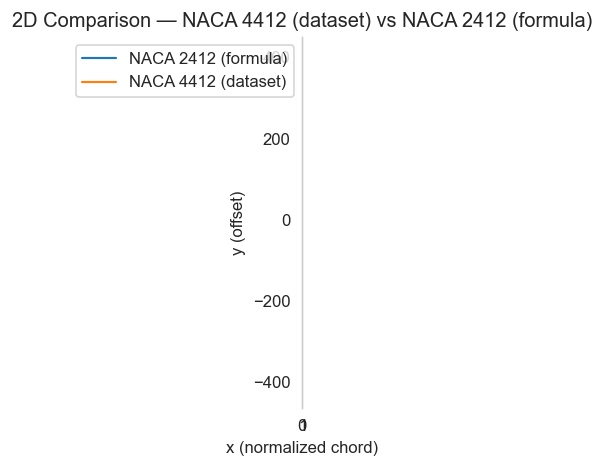

In [15]:
plt.figure(figsize=(10,4))
plt.plot(df2412['x'], df2412['y'], label='NACA 2412 (formula)', linewidth=1.3)
plt.plot(coords_clean['x'], coords_clean['y'], label='NACA 4412 (dataset)', linewidth=1.3)
plt.gca().set_aspect('equal', adjustable='box')
plt.title('2D Comparison — NACA 4412 (dataset) vs NACA 2412 (formula)')
plt.xlabel('x (normalized chord)')
plt.ylabel('y (offset)')
plt.legend()
plt.grid(linestyle='--', linewidth=0.4)
plt.tight_layout()
plt.show()


##  3D extrusion and visualization
Extrude both profiles spanwise for simple 3D visualization; export 3D point clouds.


In [16]:
def extrude_profile(x_arr, y_arr, span=0.6, n_span=80):
    z = np.linspace(-span/2, span/2, n_span)
    X = np.repeat(np.asarray(x_arr)[:, np.newaxis], n_span, axis=1)
    Y = np.repeat(np.asarray(y_arr)[:, np.newaxis], n_span, axis=1)
    Z = np.repeat(z[np.newaxis, :], X.shape[0], axis=0)
    return pd.DataFrame({'x': X.ravel(), 'y': Y.ravel(), 'z': Z.ravel()})

df3d_4412 = extrude_profile(coords_clean['x'].values, coords_clean['y'].values, span=0.6, n_span=100)
df3d_2412 = extrude_profile(df2412['x'].values, df2412['y'].values, span=0.6, n_span=100)

df3d_4412.to_csv('data/naca4412_3d_from_dataset.csv', index=False)
df3d_2412.to_csv('data/naca2412_3d_formula.csv', index=False)
df3d_4412.shape, df3d_2412.shape


((49949500, 3), (199900, 3))

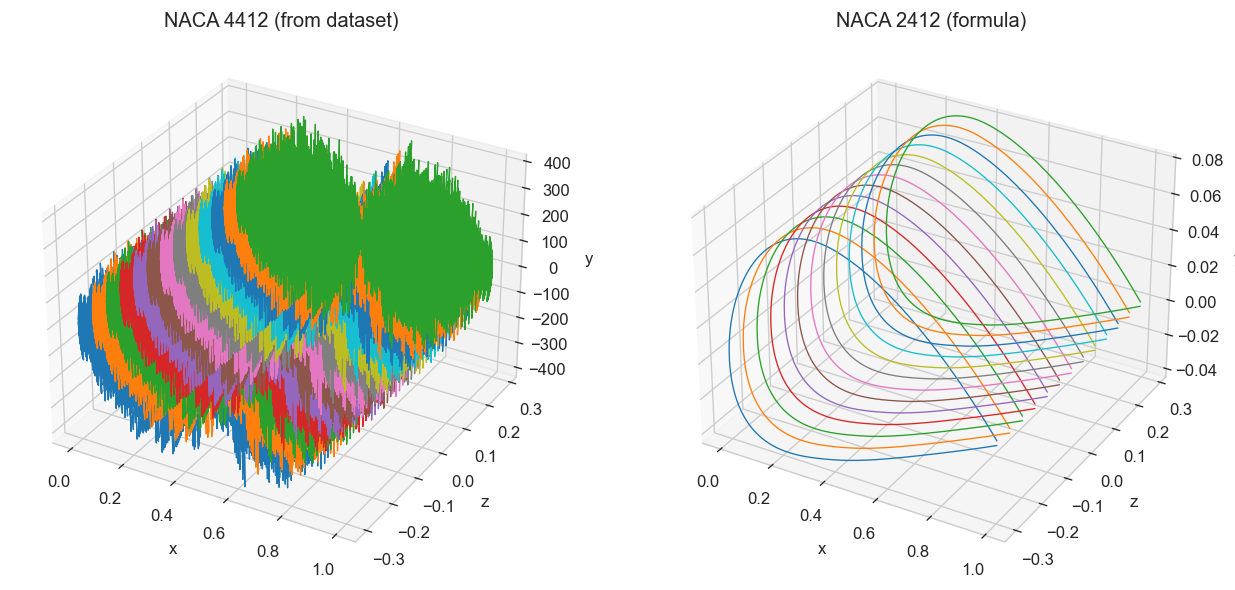

In [17]:
fig = plt.figure(figsize=(11,5))
ax1 = fig.add_subplot(121, projection='3d')
unique_z1 = np.sort(df3d_4412['z'].unique())
step1 = max(1, len(unique_z1)//12)
for i in range(0, len(unique_z1), step1):
    s = unique_z1[i]
    slice_df = df3d_4412[df3d_4412['z']==s]
    ax1.plot(slice_df['x'], slice_df['z'], slice_df['y'], linewidth=0.8)
ax1.set_title('NACA 4412 (from dataset)')
ax1.set_xlabel('x'); ax1.set_ylabel('z'); ax1.set_zlabel('y')

ax2 = fig.add_subplot(122, projection='3d')
unique_z2 = np.sort(df3d_2412['z'].unique())
step2 = max(1, len(unique_z2)//12)
for i in range(0, len(unique_z2), step2):
    s = unique_z2[i]
    slice_df = df3d_2412[df3d_2412['z']==s]
    ax2.plot(slice_df['x'], slice_df['z'], slice_df['y'], linewidth=0.8)
ax2.set_title('NACA 2412 (formula)')
ax2.set_xlabel('x'); ax2.set_ylabel('z'); ax2.set_zlabel('y')

plt.tight_layout()
plt.show()


##  Quality checks and summary
Summarize key counts, saved files, and recommend verification steps for coordinate mapping.


In [18]:
summary = {
    'original_shape': df.shape,
    'cleaned_2d_points_4412': coords_clean.shape[0],
    'naca2412_points': df2412.shape[0],
    '3d_points_4412': df3d_4412.shape[0],
    '3d_points_2412': df3d_2412.shape[0],
    'saved_files': [
        'data/naca4412_cleaned_coordinates.csv',
        'data/naca4412_3d_from_dataset.csv',
        'data/naca2412_formula_coordinates.csv',
        'data/naca2412_3d_formula.csv'
    ]
}
pd.Series(summary)


original_shape                                                  (999000, 6)
cleaned_2d_points_4412                                               499495
naca2412_points                                                        1999
3d_points_4412                                                     49949500
3d_points_2412                                                       199900
saved_files               [data/naca4412_cleaned_coordinates.csv, data/n...
dtype: object

##  Conclusions

- The uploaded NACA 4412 dataset was cleaned and a smooth 2D profile was extracted and normalized for chordwise comparison.
- A high-resolution analytical NACA 2412 profile was generated for direct visual comparison.
- Both 2D and 3D point clouds were exported for reuse (visualization, CAD import, meshing).
